# PaperTrail: Trend, State, and Policy-Impact Analysis

This notebook pulls the live incident dataset from Supabase (110 original + auto-detected incidents from the Research Agent) and analyzes it for:
- Yearly trend in reported paper leak incidents
- State-wise distribution
- Before/after comparison around the 2024 Public Examinations (Prevention of Unfair Means) Act
- A short-term forecast using ARIMA

**Note:** This is descriptive and exploratory analysis, not a rigorous causal study. Sample sizes (especially post-Act) are small, and findings should be read as observed patterns worth further investigation, not definitive conclusions.

In [1]:
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv

**Loading live data from Supabase**
<br> Pulling directly from the database (not a static CSV) so this analysis always reflects the latest state, including any incidents the Research Agent has added since the original dataset was cleaned.

In [2]:
load_dotenv()
engine = create_engine(os.getenv('DATABASE_URL'))
df = pd.read_sql("SELECT * FROM incidents", engine)
df['incident_date'] = pd.to_datetime(df['incident_date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   incident_id         112 non-null    str           
 1   incident_date       112 non-null    datetime64[s] 
 2   era                 112 non-null    str           
 3   exam_name           111 non-null    str           
 4   conducting_body     111 non-null    str           
 5   body_type           110 non-null    str           
 6   area                111 non-null    str           
 7   state_clean         111 non-null    str           
 8   leak_status         112 non-null    str           
 9   action_taken        112 non-null    str           
 10  note                112 non-null    str           
 11  arrests             63 non-null     float64       
 12  convictions         10 non-null     float64       
 13  aspirants_affected  44 non-null     float64       
 14  linke

**Yearly trend in reported incidents**
<br>Incidents were low and sporadic from 2004–2019, then rose sharply from 2021 onward. The 2021–2022 spike (14–15 incidents/year) likely reflects a backlog of exams delayed and rescheduled during the COVID-19 pandemic, though this dataset alone can't confirm that causally — it's a plausible explanation worth noting, not a proven one.

<Axes: title={'center': 'Paper Leak Incidents per Year'}, xlabel='year'>

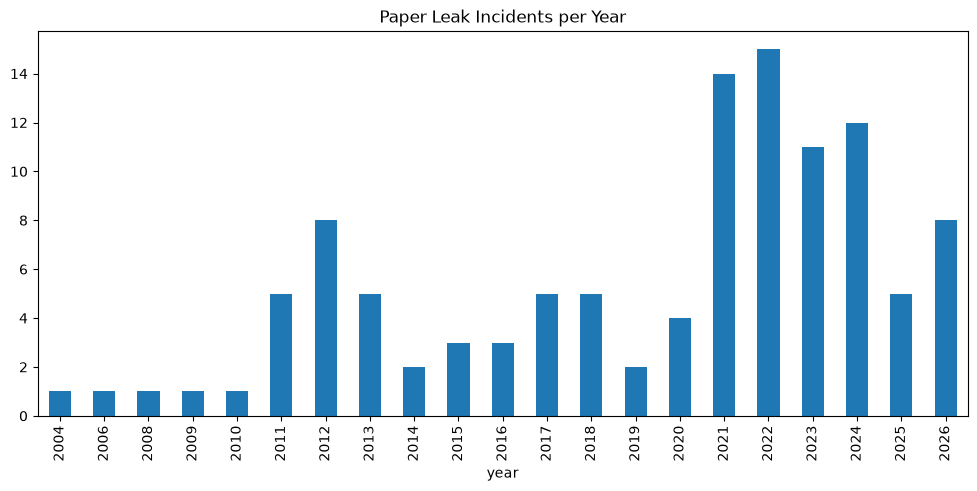

In [10]:
df['year'] = df['incident_date'].dt.year
leaks_per_year = df.groupby('year').size()
leaks_per_year.plot(kind='bar', title='Paper Leak Incidents per Year', figsize=(12,5))

**State-wise distribution**
<br>Madhya Pradesh, Uttar Pradesh, and Rajasthan account for the largest share of state-level incidents (13, 12, and 11 respectively). "All India" (16) represents leaks in centrally-conducted exams (e.g., NEET, UPSC) rather than a single state.

<Axes: title={'center': 'Top 10 States by Leak Incidents'}, ylabel='state_clean'>

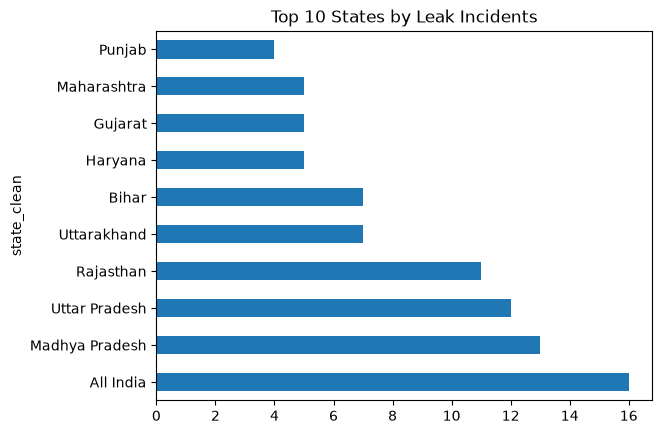

In [4]:
top_states = df['state_clean'].value_counts().head(10)
top_states.plot(kind='barh', title='Top 10 States by Leak Incidents')

**Before/after the 2024 Public Examinations Act**

In [6]:
cutoff = pd.Timestamp('2024-06-01')
df['post_act'] = df['incident_date'] >= cutoff

Comparing incidents before vs. after the Act took effect (June 2024):

- **Total incidents**: 93 before vs. 19 after, not directly comparable, since "before" spans ~20 years and "after" spans only ~2
- **Arrest rate**: stayed roughly flat (56% → 58%)
- **Confirmed-status rate**: dropped noticeably (87% → 53%)


In [7]:
comparison = df.groupby('post_act').agg(
    total_incidents=('incident_id', 'count'),
    arrests_rate=('arrests', lambda x: x.notna().mean()),
    confirmed_rate=('leak_status', lambda x: (x == 'Confirmed').mean())
)
comparison.index = ['Before Act (pre-Jun 2024)', 'After Act (post-Jun 2024)']
comparison

,total_incidents,arrests_rate,confirmed_rate
Before Act (pre-Jun 2024),93,0.559140,0.870968
After Act (post-Jun 2024),19,0.578947,0.526316


**Interpretation caution:** the drop in confirmed-rate could reflect either fewer verified leaks post-Act, or more incidents currently sitting in "Alleged"/"Suspected" status pending investigation under the Act's newer legal process. The small post-Act sample size (19 incidents) means this should be read as an early signal, not a settled result.

**Short-term forecast (ARIMA)**
A basic ARIMA(1,1,1) model projects roughly 8 incidents per year for 2027 and 2028, broadly in line with the recent trend. With only ~20 years of yearly data, this is a directional estimate rather than a precise prediction.

In [9]:
from statsmodels.tsa.arima.model import ARIMA
yearly_counts = df.groupby(df['incident_date'].dt.year).size()
yearly_counts.index = pd.to_datetime(yearly_counts.index, format='%Y')
yearly_counts = yearly_counts.asfreq('YS')  # explicitly mark yearly frequency, fills gaps with NaN if any year had zero incidents

model = ARIMA(yearly_counts, order=(1,1,1))
fit = model.fit()
forecast = fit.forecast(steps=2)
print(forecast)

2027-01-01    7.961885
2028-01-01    7.940525
Freq: YS-JAN, Name: predicted_mean, dtype: float64


## Summary
This analysis is wrapped into a reusable function in `src/agents/analyst_agent.py`, which outputs a structured JSON result consumed by the Writer Agent to auto-generate a readable policy-brief report.